# Fase 2: Pré-processamento
Conforme a framework base definida no GitHub (MONAI), vamos testar aqui o pipeline de imagem.

### 1. Importações Iniciais


In [9]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

# Importações da Framework MONAI (usada no baseline do github)
from monai.transforms import Compose, Resize, NormalizeIntensity, EnsureChannelFirst, ToTensor, SpatialPad, Lambda

print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


### 2. Carregar Imagem e Aplicar CLAHE (OpenCV)
O CLAHE é uma técnica de engenharia de imagem crucial para imagens fluoroscópicas, aplicada antes dos tensores.

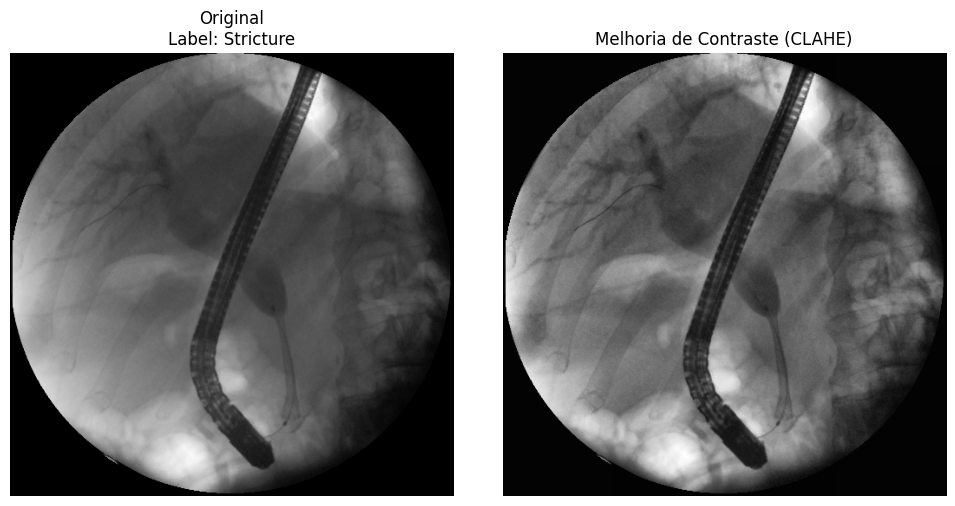

In [10]:
data_dir = '../data/'
csv_path = '../data/processed/train_split.csv'
df = pd.read_csv(csv_path)

idx = 10
img_path = os.path.join(data_dir, df.iloc[idx]['processed_image_path'])
label = df.iloc[idx]['Label']

# Carregar e aplicar CLAHE via OpenCV (Mundo NumPy)
image_bgr = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
# Aplicar a cada canal do RGB para manter as cores intactas (embora o raio-X seja P&B, o formato é 3 canais)
image_clahe = np.empty_like(image_rgb)
for i in range(3):
    image_clahe[:, :, i] = clahe.apply(image_rgb[:, :, i])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_rgb)
axes[0].set_title(f'Original\nLabel: {label}')
axes[0].axis('off')

axes[1].imshow(image_clahe)
axes[1].set_title('Melhoria de Contraste (CLAHE)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### 3. Pipeline Final do Modelo (MONAI)
Vamos aplicar a normalização e o redimensionamento usando a framework que o professor adotou no repositório oficial.

In [11]:
# Transformações MONAI 
def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

monai_transform = Compose([
    ToTensor(),
    EnsureChannelFirst(channel_dim=-1), # Muda de (H,W,C) para (C,H,W) - Padrão do PyTorch
    Resize(spatial_size=(512, 512)), # Redimensionamento
    NormalizeIntensity(), # Normalização padrão do MONAI
    Lambda(repeat_if_needed)
])

# Aplicar o pipeline do modelo
tensor_image = monai_transform(image_clahe)

print("--- Output final para o Modelo (MONAI) ---")
print(f"Shape Final: {tensor_image.shape} (Canais, Altura, Largura)")
print(f"Tipo: {tensor_image.dtype}")
print(f"Valores Min/Max Normalizados: {tensor_image.min().item():.3f} a {tensor_image.max().item():.3f}")


--- Output final para o Modelo (MONAI) ---
Shape Final: torch.Size([3, 512, 512]) (Canais, Altura, Largura)
Tipo: torch.float32
Valores Min/Max Normalizados: -1.365 a 3.051


### 4. Data Augmentation (Apenas para Treino)
Para evitar que o modelo memorize as imagens (overfitting) e ganhe maior capacidade de generalização, aplicamos **Data Augmentation** no conjunto de treino. 

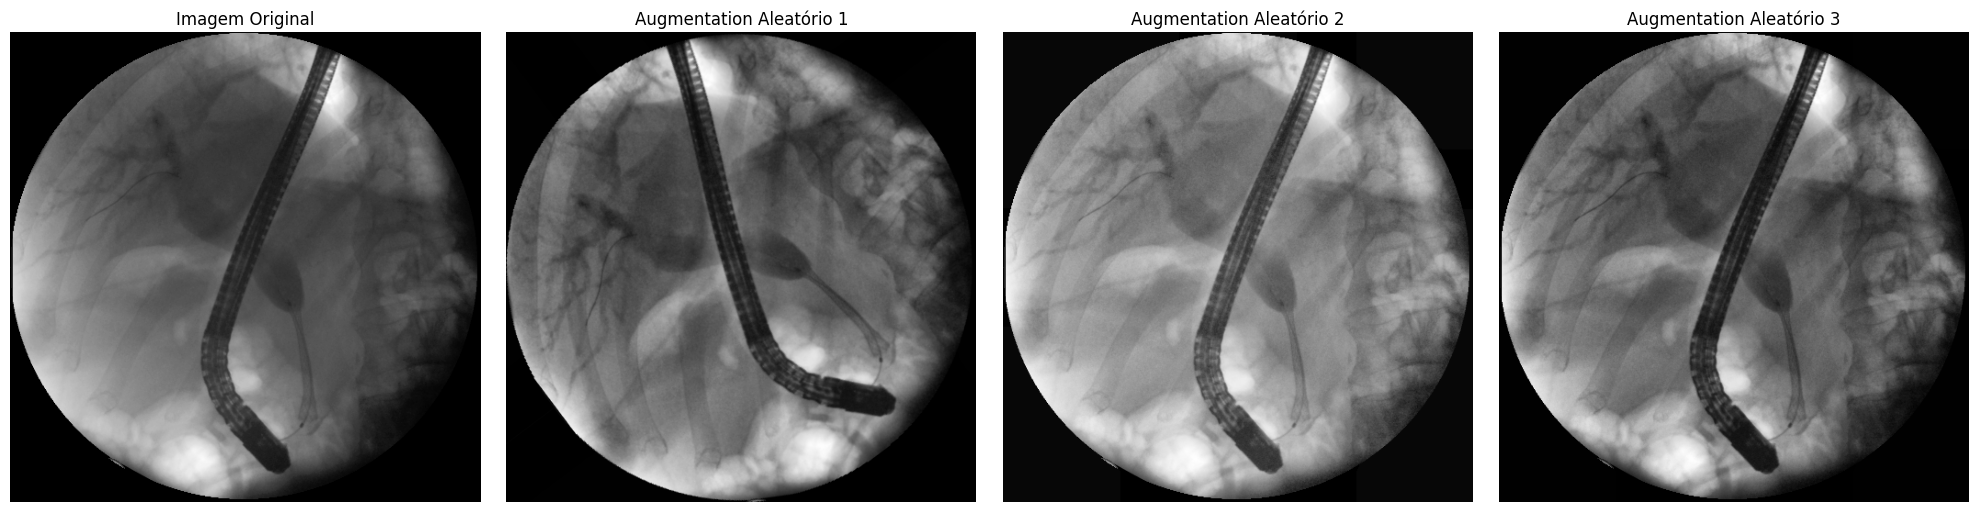

In [12]:
from monai.transforms import RandRotate, RandZoom, RandAdjustContrast, RandGaussianNoise

# Pipeline de Augmentation 
train_transform = Compose([
    ToTensor(),
    EnsureChannelFirst(channel_dim=-1),
    Resize(spatial_size=(512, 512)),
    RandRotate(range_x=15, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.01),
    NormalizeIntensity(),
    Lambda(repeat_if_needed)
])

# Criar variações da mesma imagem
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(image_rgb)
axes[0].set_title('Imagem Original')
axes[0].axis('off')

for i in range(1, 4):
    # O train_transform aplica as probabilidades aleatórias em cada chamada
    aug_tensor = train_transform(image_clahe)
    # Converter de volta para (H, W, C) para visualização
    aug_img = aug_tensor.permute(1, 2, 0).numpy()
    
    # Desfazer normalização visual apenas para plotar (aproximado)
    aug_img = (aug_img - aug_img.min()) / (aug_img.max() - aug_img.min() + 1e-8)
    
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmentation Aleatório {i}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### 5. Estratégia de Balanço e Funções de Perda
Como o dataset é desequilibrado (há muito mais imagens de 'Lithiasis' do que de 'Leaks'), precisamos de garantir que o modelo não ignora as classes mais raras.

**Cálculo de Class Weights**
Podemos calcular o peso de cada classe e passa-lo a uma função como `CrossEntropyLoss(weight=class_weights)`. 

**Focal Loss (Abordagem do Professor)**
A alternativa mais avançada (e usada na baseline do github) é usar a `FocalLoss`. Esta função lida nativamente com o desequilíbrio, aplicando uma penalização muito mais alta se o modelo falhar nas amostras difíceis (raras) do que nas fáceis.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn

# Usar o CSV de Treino guardada na Fase 1
train_csv_path = '../data/processed/train_split.csv'
if os.path.exists(train_csv_path):
    df_train = pd.read_csv(train_csv_path)
    
    # Calcular os pesos
    classes = np.unique(df_train['Label'])
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=df_train['Label'])
    
    print("--- Class Weights Calculados ---")
    for c, w in zip(classes, weights):
        print(f"Classe {c}: Peso = {w:.3f}")
        
    # Como passaríamos para o PyTorch (exemplo CrossEntropyLoss):
    tensor_weights = torch.tensor(weights, dtype=torch.float32)
    loss_ce = nn.CrossEntropyLoss(weight=tensor_weights)
    print("\nLoss de CrossEntropy Ponderada configurada (Opcional).")

else:
    print("O ficheiro de treino não foi encontrado.")

# --- Demonstração ---
from monai.losses import FocalLoss
# to_onehot_y=True é essencial porque o modelo fará output de probabilidades por classe
loss_focal = FocalLoss(to_onehot_y=True) 
print("Loss Assimétrica (Focal Loss) carregada conforme Baseline.")


--- Class Weights Calculados ---
Classe Biliary Leaks: Peso = 2.425
Classe Lithiasis: Peso = 0.528
Classe Normal: Peso = 1.354
Classe Stricture: Peso = 1.046

Loss de CrossEntropy Ponderada configurada (Opcional).
Loss Assimétrica (Focal Loss) carregada conforme Baseline.
